
# Tasks

Program a variational auto-encoder (VAE) and train it with the Fashion-MNIST dataset. Use the starter code below: it tells you exactly where you need to add code. Use convolutional processing in the encoder and decoder. Try out various hyperparameters, eg kernel sizes, BatchNorm, Dropout, Pooling, latent space size, KL regularisation term lambda, called `lmbda` below to avoid a Python keyword clash, different number of epochs.

Write your VAE using classes and functions so that you can easily create a new model and retrain just by calling existing classes and functions with new parameters, ie without copy-pasting all the code and then editing it.

Observe the results closely in several ways:

   1. History of train and test loss
   2. Distribution in latent space
   3. Quality of generated points over a grid in the latent space (only works where latent space is 2D)
   4. Quality of reconstructions



# Setup and data loading

In [ ]:
# This cell is complete: you don't need to change anything

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

import numpy as np
import matplotlib.pyplot as plt

def get_device():
    """Return the best available device: CUDA > MPS (Apple) > XLA (TPU) > CPU."""
    if torch.cuda.is_available():
        return torch.device('cuda')
    if torch.backends.mps.is_available():
        return torch.device('mps')
    try:
        import torch_xla.core.xla_model as xm
        return xm.xla_device()
    except ImportError:
        pass
    return torch.device('cpu')

device = get_device()
print(f"Using device: {device}")

Using device: cuda


In [ ]:
# This cell is complete: you don't need to change anything

# load the data

transform = transforms.ToTensor()  # scales pixels to [0, 1]

train_dataset = datasets.FashionMNIST(root='./data', train=True,  download=True, transform=transform)
test_dataset  = datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

# pin_memory speeds up host→GPU transfers; only meaningful for CUDA
pin = isinstance(device, torch.device) and device.type == 'cuda'

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True,  num_workers=2, pin_memory=pin)
test_loader  = DataLoader(test_dataset,  batch_size=128, shuffle=False, num_workers=2, pin_memory=pin)

x_viz, y_viz = next(iter(DataLoader(train_dataset, batch_size=500)))

print(f"Train batches: {len(train_loader)}, Test batches: {len(test_loader)}")

Train batches: 469, Test batches: 79


# Visualisations

The next cell contains four functions which make useful plots you should look at for each of your models.

In [ ]:
# This cell is complete: you don't need to write anything here.

def plot_history(history):
    """
    Plot training and test loss curves from the dict returned by train_vae.
    Three subplots: total loss, reconstruction loss, and KL loss.
    """
    epochs = range(1, len(history['train_loss']) + 1)

    fig, axes = plt.subplots(1, 3, figsize=(12, 3))
    for ax, (title, train_key, test_key) in zip(axes, [
        ("Total loss",          "train_loss",  "test_loss"),
        ("Reconstruction loss", "train_recon", "test_recon"),
        ("KL loss",             "train_kl",    "test_kl"),
    ]):
        ax.plot(epochs, history[train_key], label="train")
        ax.plot(epochs, history[test_key],  label="test")
        ax.set_title(title)
        ax.set_xlabel("Epoch")
        ax.legend()

    plt.tight_layout()
    plt.show()


def plot_latent_points(encoder, images, labels):
    """
    Encode a batch of images and scatter-plot their mu values in latent space.
    Colours correspond to the 10 classes.
    If the latent space is more than 2D, only the first two latent dimensions are shown.
    """
    fig, ax = plt.subplots()

    was_training = encoder.training
    encoder.eval()
    with torch.no_grad():
        mu, _ = encoder(images.to(device))
    encoder.train(was_training)
    z = mu.cpu().numpy()

    # vmin/vmax of -0.5..9.5 centres each integer on its colour band
    cmap = plt.get_cmap('tab10')
    scatter = ax.scatter(z[:, 0], z[:, 1], c=labels.numpy(),
                         cmap=cmap, vmin=-0.5, vmax=9.5)
    fig.colorbar(scatter, ax=ax, fraction=0.046, pad=0.04, ticks=range(10))

    ax.set_xlabel("z[0]")
    ax.set_ylabel("z[1]")
    ax.set_aspect('equal', adjustable='box')
    plt.show()



def plot_latent_space(decoder, n=10, figsize=10):
    """
    Display a grid of sampled images - ie iterate over a grid
    in the latent space and for each point in the grid,
    decode that point to get an image, and view that image.
    This only works when the VAE latent space is size z=2.
    """

    assert decoder.latent_size == 2

    image_size = 28

    # we'll look at a grid of [-scale, +scale]^2.
    scale = 2.0

    figure = np.zeros((image_size * n, image_size * n))
    grid_x = np.linspace(-scale, scale, n)
    grid_y = np.linspace(-scale, scale, n)[::-1]

    was_training = decoder.training
    decoder.eval()
    with torch.no_grad():
        for i, yi in enumerate(grid_y):
            for j, xi in enumerate(grid_x):
                z_sample = torch.tensor([[xi, yi]], dtype=torch.float32).to(device)
                x_decoded = decoder(z_sample).cpu().numpy()
                digit = x_decoded[0].reshape(image_size, image_size)
                figure[
                    i * image_size : (i + 1) * image_size,
                    j * image_size : (j + 1) * image_size,
                ] = digit
    decoder.train(was_training)

    plt.figure(figsize=(figsize, figsize))
    start_range = image_size // 2
    end_range = n * image_size + start_range
    pixel_range = np.arange(start_range, end_range, image_size)
    sample_range_x = np.round(grid_x, 1)
    sample_range_y = np.round(grid_y, 1)
    plt.xticks(pixel_range, sample_range_x)
    plt.yticks(pixel_range, sample_range_y)
    plt.xlabel("z[0]")
    plt.ylabel("z[1]")
    plt.imshow(figure, cmap="Greys")
    # plt.savefig("vae_latent_space.pdf")
    plt.show()


def plot_reconstructions(model, images, max_images=10):
    """
    Encode a batch of images through the VAE and display originals
    alongside their reconstructions.
    Top row: original images.  Bottom row: reconstructions.
    At most max_images columns are shown.
    """
    n = min(max_images, images.size(0))
    images = images[:n]

    was_training = model.training
    model.eval()
    with torch.no_grad():
        recon, _, _ = model(images.to(device))
    model.train(was_training)
    recon = recon.cpu()

    fig, axes = plt.subplots(2, n, figsize=(n * 1.5, 3))
    fig.text(0.01, 0.75, "Original",       va='center', rotation='vertical')
    fig.text(0.01, 0.25, "Reconstruction", va='center', rotation='vertical')

    for j in range(n):
        for row, img in enumerate([images[j], recon[j]]):
            axes[row, j].imshow(img.squeeze(), cmap='Greys')
            axes[row, j].axis('off')

    plt.tight_layout()
    plt.show()


# Task: complete the Encoder and Decoder

In [ ]:
class Encoder(nn.Module):
    def __init__(self, kernels, flat_size, latent_size):
        super().__init__()
        k = kernels
        self.latent_size = latent_size

        ## YOUR CODE HERE: create the layers

        self.conv_layers = nn.Sequential(
            # Block 1
            nn.Conv2d(1, k[0], kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(k[0]),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            # Block 2
            nn.Conv2d(k[0], k[1], kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(k[1]),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            # Block 3
            nn.Conv2d(k[1], k[2], kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(k[2]),
            nn.ReLU(),
            # No pooling here: keep 7x7
        )

        self.fc_mu      = nn.Linear(flat_size, latent_size)
        self.fc_log_var = nn.Linear(flat_size, latent_size)


    def forward(self, x):
       ## YOUR CODE HERE: run the layers and return z_mu, z_log_var
        h = self.conv_layers(x)
        h = h.view(h.size(0), -1)
        z_mu      = self.fc_mu(h)
        z_log_var = self.fc_log_var(h)
        return z_mu, z_log_var

class Decoder(nn.Module) :
    def __init__(self, kernels, flat_size, latent_size):
        super().__init__()
        k = kernels
        self.latent_size = latent_size
        self._k2 = k[2]

        ## YOUR CODE HERE: create the layers
        self._flat_size = flat_size

        self.fc = nn.Linear(latent_size, flat_size)

        self.deconv_layers = nn.Sequential(

            nn.ConvTranspose2d(k[2], k[1], kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(k[1]),
            nn.ReLU(),

            # Block 2: 14x14 -> 28x28
            nn.ConvTranspose2d(k[1], k[0], kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(k[0]),
            nn.ReLU(),

            # Block 3: refine at 28x28, output 1 channel
            nn.Conv2d(k[0], 1, kernel_size=3, stride=1, padding=1),
            nn.Sigmoid(),   # pixels in [0,1] to match ToTensor() normalisation
        )

    def forward(self, z):
        ## YOUR CODE HERE: run the layers and return xhat
        h = self.fc(z)
        h = F.relu(h)
        h = h.view(h.size(0), self._k2, 7, 7)
        x_hat = self.deconv_layers(h)
        return x_hat


# Task: run the Encoder and Decoder stand-alone to make sure they work


In [ ]:
x = train_dataset.data[:10].unsqueeze(1).float() / 255.0 # first 10 images

## YOUR CODE HERE:
# Call your Encoder (defined above, not yet trained)
# to process this x, and print the shape of the result.
# Then call your Decoder (defined above, not yet trained)
# to process the result from above, and print the shape of the new result.


kernels     = [32, 64, 128]
flat_size   = kernels[2] * 7 * 7   # 128 * 7 * 7 = 6272
latent_size = 2


encoder = Encoder(kernels, flat_size, latent_size).to(device)
decoder = Decoder(kernels, flat_size, latent_size).to(device)


x = x.to(device)
z_mu, z_log_var = encoder(x)
print(f"Input x shape    : {x.shape}")        # (10, 1, 28, 28)
print(f"z_mu shape       : {z_mu.shape}")     # (10, 2)
print(f"z_log_var shape  : {z_log_var.shape}")# (10, 2)


epsilon = torch.randn_like(z_mu)
z = z_mu + torch.exp(0.5 * z_log_var) * epsilon
print(f"z shape          : {z.shape}")        # (10, 2)


x_hat = decoder(z)
print(f"x_hat shape      : {x_hat.shape}")   # (10, 1, 28, 28)



Input x shape    : torch.Size([10, 1, 28, 28])
z_mu shape       : torch.Size([10, 2])
z_log_var shape  : torch.Size([10, 2])
z shape          : torch.Size([10, 2])
x_hat shape      : torch.Size([10, 1, 28, 28])


Building the VAE from two halves, an Encoder and a Decoder.
The Encoder takes the Fashion-MNIST image and compressess it into a smal latent representation.

In the first stage The three convolutional blocks (Block 1, Block 2, Block 3) shrink the image while detecting features.

The input image is a grayscale image, Block 1 detects the edges and corners, Block 2 detects the shapes, textures and Block 3 detects the complex features.

In each block Conv2d scans the image with learned filters to detect features.
BatchNorm2d stabilises trainingg by normalizing layer outpts.
ReLU removes negatives values and keeps only active features.
MaxPool2d(2,2) halves spatial size ( 28 --> 14 -->7)

VAE outputs two vectors per image : z_mu ( where in latent space this image most likely belongs) and z_log_var ( how uncertain we are about the location)

The Decoder takes a samples latent vector z and rescontructs the original image.
ConvTranspose2d is the reverse of Conv+pool as it grows the spatial dimensions instead of shrinking them. The sigmoid() ensures all pixel values are in the range of 0 and 1.

The variable x takes in 10 raw images and prepares them to verify the encoder and decoder is working correctly, .unsqueeze(1) adds one channel dimension, /255.0 scales pixels from [0,255] to [0,1]

10 images are passed through the encoder which returns two vectors per image.
Through Reparameterisation sampling , it samples a z point from the distribution defined by z_mu and z_log_var ( Reparameterisation trick)
The sampled `z` is passed through the decoder to get a reconstructed image.



# Task: write a short note in this cell to explain the shapes you observe.

My observations are The encoder compressed 28×28 = 784 numbers down to just 2 numbers per image. The decoder rebuilt it back to 784 numbers.

Input x --> (10, 1, 28, 28) --> This means that for the 10 raw images, 1 channel was used,  28×28 pixels

z_mu --> (10, 2) --> 1 mean point per image in 2D latent space

z_log_var --> (10, 2) --> 1 uncertainty value per image in 2D latent space

z --> (10, 2) --> 1 sampled latent point per image

x_hat --> (10, 1, 28, 28) --> Reconstructed images, same shape as input

The output x_hat matches the shape of the input x, this confirms that it works correctly even before any training has taken place.


# Task: complete the VAE

In [ ]:
class VAE(nn.Module):
    def __init__(self, kernels, flat_size, latent_size):
        super().__init__()
        self.encoder = Encoder(kernels, flat_size, latent_size)
        self.decoder = Decoder(kernels, flat_size, latent_size)

    # this part samples from N(mu, std)
    def reparameterise(self, mu, log_var):
        std = torch.exp(0.5 * log_var)
        return mu + std * torch.randn_like(std)

    def forward(self, x):
        ## YOUR CODE HERE: run the VAE and return the variables shown below
        # Step 1: encode x → get mu and log_var
        mu, log_var = self.encoder(x)

        # Step 2: sample z using reparameterisation trick

        z = self.reparameterise(mu, log_var)

        # Step 3: decode z → get reconstruction
        recon = self.decoder(z)
        return recon, mu, log_var


In [ ]:
# this is a convenience function to build the VAE by using the VAE class we defined above

# This cell is complete: you don't have to write anything

def make_vae(kernels_per_layer=(8, 16, 24),
             flat_size=24*4*4,
             latent_size=32):
    """
    Build a small convolutional VAE for Fashion-MNIST (1x28x28 inputs).
    Returns a VAE with .encoder and .decoder attributes, each an nn.Module.

    Args:
        kernels_per_layer: tuple of 3 ints — channels at each conv layer.
        latent_size: dimensionality of z.
    """
    k = kernels_per_layer
    assert len(k) == 3, "Currently designed for exactly 3 conv layers."
    return VAE(k, flat_size, latent_size)

In the above task : Complete the VAE, we combine the Encoder and Decoder that we built into a simple complete VAE model. The VAE class acts as a wrapper that connects the three key steps : VAE = AE + Sampling + Kullback-Leibler regularisation.
In the function reparameterise, Instead of outputting a single fixed point `z`, it outputs a distribution described by `mu` (centre) and `std` (spread). We then **sample** a `z` from that distribution.
By sampling different `z` points each time, the decoder is forced to learn that nearby points in latent space should produce similar images.
In forward pass , in the step 1 Encoder outputs not z, but mu and sigma
In step 2 : Sampling operation chooses z.
In step 3 : decode, Decoder takes in z to produce reconstructed image.
All three outputs (recon, mu, log_var) are returned as the loss function needs it to measure reconstruction quality, and mu/log_var to compute the KL regularisation term.

# Task: complete the VAE loss

In [ ]:
def vae_loss(recon, x, mu, log_var, lmbda=1.0):
    """
    VAE loss = reconstruction loss + lmbda * KL divergence.

    Args:
        recon:   reconstructed images,  shape (B, 1, 28, 28), values in [0,1]
        x:       original images,       shape (B, 1, 28, 28), values in [0,1]
        mu:      encoder mean,          shape (B, latent_size)
        log_var: encoder log-variance,  shape (B, latent_size)
        lmbda:  weight on the KL term (lmbda=1 is a standard VAE;
                 lmbda>1 encourages a more disentangled latent space)

    Returns:
        loss:        scalar total loss (mean over batch), a weighted sum of recon and kl
        recon_loss:  reconstruction term alone
        kl_loss:     KL term alone
    """
    # Binary cross-entropy over pixels
    # Sum BCE over pixels, take mean over batch
    recon_loss = F.binary_cross_entropy(recon, x, reduction='sum') / x.size(0)


    # KL( q(z|x) || N(0,I) ) closed form - this line is complete
    kl_loss = -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp()) / x.size(0)

    ## take the appropriate weighted sum of the losses
    weighted_sum = recon_loss + lmbda * kl_loss

    return weighted_sum, recon_loss, kl_loss

In this task, The VAE loss function measures how well the model is doing during training.
Loss = Reconstruction Loss + lambda × KL Loss

recon_loss, measures how different the reconstructed image is from the original.
Binary Cross Entropy is used because, Pixel values are in [0,1], BCE treats each pixel as a probability, reduction='sum' adds up all pixel errors across the image.
Dividing by x.size(0) (batch size) gives the average per image.
A low reconstruction loss means the model is rebuilding images accurately.

KL Loss measures how far the learned latent distribution is from a standard Normal N(0,1)
As explained in the lecture the regularisation procedure adds a loss to push the overall latent distribution to be similar to a standard Multivariate normal N(0,1).
A low KL loss would mean that the latent space is easy to sample from.

Lambda parameter is used to control the balance between the two losses , as if the lambda is too large the model collapses and no variety in outputs. Lambda is too small it is equivalent to a classic AE. if the lambda value is around 1.0 it is a balanced, standard VAE.

# Task: fill in missing lines to run an epoch

In [ ]:
def run_epoch(model, loader, optimizer, lmbda, device, train=True):
    model.train(train) # put the model in train mode
    total_loss = total_recon = total_kl = 0.0
    with torch.set_grad_enabled(train): # the model will calculate gradients
        for x, _ in loader:
            x = x.to(device)

            ## YOUR CODE HERE
            # run the model on x and call vae_loss
            recon, mu, log_var = model(x)
            loss, recon_loss, kl_loss = vae_loss(recon, x, mu, log_var, lmbda)


            if train:

                ## YOUR CODE HERE
                # set gradients to zero, run backward pass, and step the optimizer
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()



            n = x.size(0)
            total_loss  += loss.item()       * n
            total_recon += recon_loss.item() * n
            total_kl    += kl_loss.item()    * n
    N = len(loader.dataset)
    return total_loss / N, total_recon / N, total_kl / N


In [ ]:
# This cell is complete. You don't need to write anything.


def train_vae(model, train_loader, test_loader, epochs=20, lr=1e-3, lmbda=1.0, device='cpu'):
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr) # Adam optimizer. Not too sensitive to initial LR
    history = {'train_loss': [], 'test_loss': [], 'train_recon': [], 'test_recon': [], 'train_kl': [], 'test_kl': []}
    for epoch in range(0, epochs + 1):
        if epoch == 0:
            # we run the train and test data forward at epoch zero but don't train
            # just observe the losses so we know how they change from the very start
            train = False
        else:
            train = True
        tr_loss, tr_recon, tr_kl = run_epoch(model, train_loader, optimizer, lmbda, device, train=train)
        te_loss, te_recon, te_kl = run_epoch(model, test_loader,  optimizer, lmbda, device, train=False)
        for k_, v in [('train_loss', tr_loss), ('test_loss', te_loss),
                      ('train_recon', tr_recon), ('test_recon', te_recon),
                      ('train_kl', tr_kl), ('test_kl', te_kl)]:
            history[k_].append(v)
        print(f"Epoch {epoch:3d}/{epochs} | "
              f"train loss {tr_loss:.2f} (recon {tr_recon:.2f}, KL {tr_kl:.2f}) | "
              f"test loss {te_loss:.2f} (recon {te_recon:.2f}, KL {te_kl:.2f})")
    return history


In this Task we update the model weights by going through the dataset one epoch at a time.
model(x) calls VAE.forward(), runs encoder, sampling, and decoder.

vae_loss() computes how well the model did on this batch.
The three loss values are returned.
If train = True, zero_grad() Clears gradients from previous batch as pytorch accumulates gradients by default.
backward(), calculates how to adjust each weight to understand which direction reduces the loss.
step(), Updates all weights

return total_loss / N, gives the true average loss per image across the entire dataset.

The train_vae function manages the complete multi epoch training process.

# Task: create and train the model

In [ ]:
## YOUR CODE HERE
# call make_vae and train_vae
# look carefully at their function signatures
# train_vae should return history which we need later

# Step 1: create a smaller, faster VAE
model = make_vae(
    kernels_per_layer = (16, 32, 64),
    flat_size         = 64 * 7 * 7,
    latent_size       = 2
)

# Step 2: train with fewer epochs first to test
history = train_vae(
    model        = model,
    train_loader = train_loader,
    test_loader  = test_loader,
    epochs       = 10,
    lr           = 1e-3,
    lmbda        = 1.0,
    device       = device
)

Epoch   0/10 | train loss 532.43 (recon 532.43, KL 0.00) | test loss 532.47 (recon 532.47, KL 0.00)
Epoch   1/10 | train loss 288.75 (recon 282.57, KL 6.18) | test loss 274.02 (recon 267.50, KL 6.52)
Epoch   2/10 | train loss 269.35 (recon 263.02, KL 6.34) | test loss 271.10 (recon 264.89, KL 6.21)
Epoch   3/10 | train loss 266.97 (recon 260.62, KL 6.35) | test loss 269.53 (recon 263.15, KL 6.39)
Epoch   4/10 | train loss 265.19 (recon 258.90, KL 6.28) | test loss 269.30 (recon 262.94, KL 6.36)
Epoch   5/10 | train loss 264.11 (recon 257.81, KL 6.29) | test loss 266.96 (recon 260.64, KL 6.32)
Epoch   6/10 | train loss 263.29 (recon 256.99, KL 6.30) | test loss 264.06 (recon 257.89, KL 6.17)
Epoch   7/10 | train loss 262.77 (recon 256.50, KL 6.28) | test loss 264.11 (recon 257.82, KL 6.29)
Epoch   8/10 | train loss 262.02 (recon 255.75, KL 6.27) | test loss 263.31 (recon 256.97, KL 6.34)
Epoch   9/10 | train loss 261.63 (recon 255.35, KL 6.28) | test loss 264.07 (recon 257.86, KL 6.20)


In this task we created and trained the first complete VAE model, here the goal was to train the model to compress Fashion-MNIST clothing images into a small latent space and reconstruct them back.
In Step1 we create the model using kernels_per_layer = (16, 32, 64)
The 3 convolutional layers have 16, 32 and 64 filters. It is small enough to train quickly and large enough to learn meaningful features.
After the three convolutional blocks, the feature map is 64 channels × 7×7 spatial size. This must be flattened before the linear layers.

The latent size is set to 2 dimensions which is kept small as it forces the model to learn the most essential features for each image.

In the next step  model trains for 10 complete passes. This is a good starting point for a 2D latent space model.

The learning rate of 0.001 is the standard starting point for the Adam optimiser.
The KL regularisation weight (lambda) is set to 1.0 as a standard starting point.

Initially Loss was very high, the model had random weights and could not reconstruct anything, In the next epoch Loss almost halved and it continued decreasing.
Train and test loss are almost identical throughout training, this confirms no overfitting and the model generalises well to unseen images

# Task: use our visualisation functions to see how the training went and how the model behaves

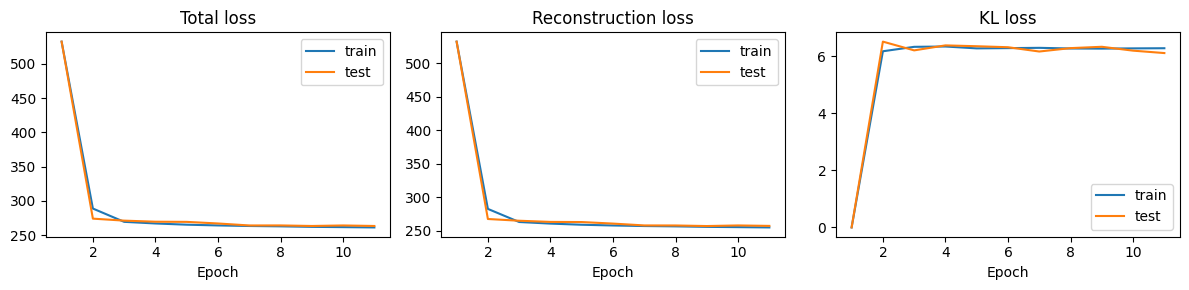

In [ ]:
plot_history(history) # history available from the train_vae() call above

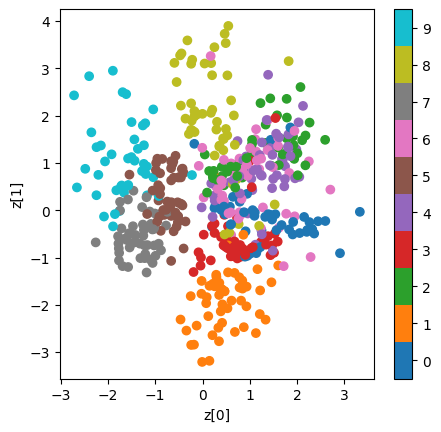

In [ ]:
plot_latent_points(model.encoder, x_viz, y_viz)

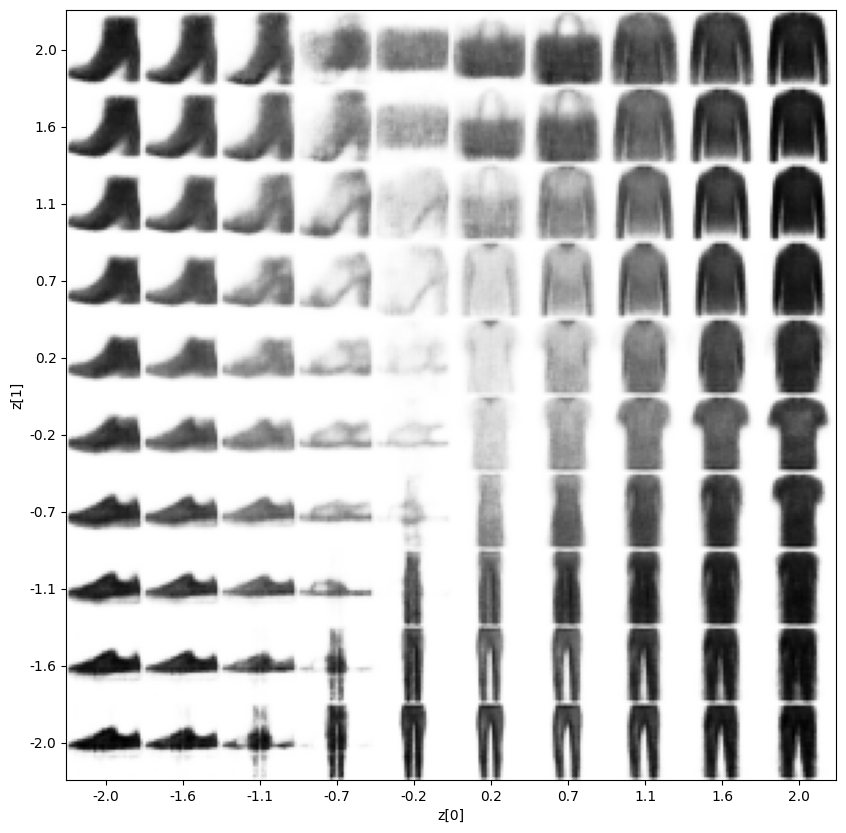

In [ ]:
plot_latent_space(model.decoder, n=10, figsize=10) # this one works only for 2D latent space

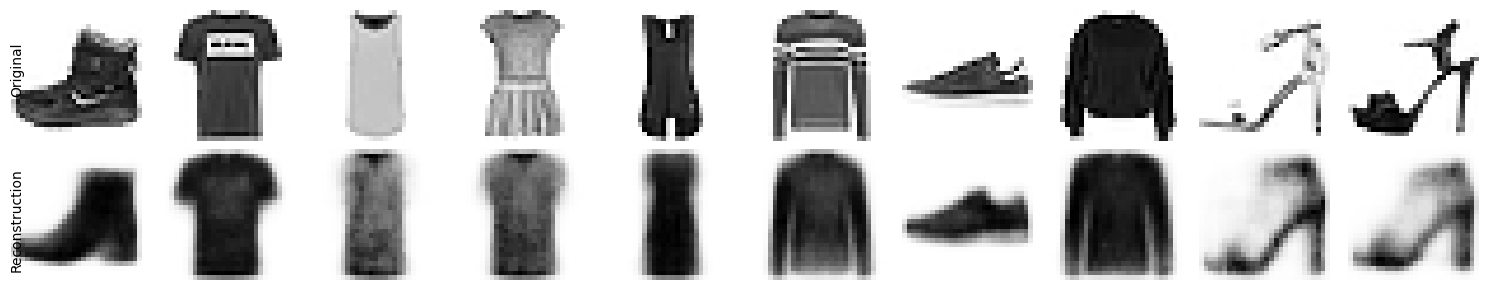

In [ ]:

plot_reconstructions(model, x_viz)

In the first plot, Total Loss and Reconstruction Loss Both show the same pattern a sharp drop at epoch 1, and gradual flattening. Train (blue) and test (orange) lines are nearly identical.
The curve is largely flat from epoch 4 onwards which indicates that the model has converged

KL Loss
Increased from 0 to almost 6 at epoch 1 then stabilised

Plot 2: Latent Space Shows where 500 images land in the 2D latent space, coloured by clothing class.
The Classes occupy distinct regions of the latent space without ever being told the labels
- Class 1 (trousers, orange) clearly separated at bottom-right
- Class 8 (bags, yellow-green) clearly separated at left
- Class 7 (sneakers, grey) forms its own cluster

- Classes 2, 3, 4, 5 (tops, pullovers, dresses, coats) overlap in the centre, as these items look visually similar

Moving gradually across the grid shows clothing types morphing smoothly into each other, shoes gradually become boots, tops gradually become sweaters.

Plot 4: Reconstructions

Simple solid items such as boots, t-shirts, sweaters reconstruct well. whereas Detailed items (stripes, thin heels) lose fine detail
As mentioned in the lecture "Good reconstructions => no important information was lost in compressio"
The reconstructions confirm the model has successfully learned the essential shapes and structure of Fashion-MNIST clothing items, even when compressing each image into just 2 numbers.

# Task: repeat the training for several different configurations

Eg, architectures, latent space size, number of epochs.

Include 3 different configurations in your notebook. For each, include the visualisations.

At the end, write a note to explain which of these configurations is your best model.

Before submitting, assign your **best trained model** to `best_model` in the cell below

Epoch   0/10 | train loss 563.00 (recon 563.00, KL 0.00) | test loss 562.93 (recon 562.93, KL 0.00)
Epoch   1/10 | train loss 302.20 (recon 296.35, KL 5.84) | test loss 275.28 (recon 269.07, KL 6.20)
Epoch   2/10 | train loss 272.03 (recon 265.84, KL 6.19) | test loss 271.95 (recon 265.81, KL 6.14)
Epoch   3/10 | train loss 268.97 (recon 262.78, KL 6.19) | test loss 270.50 (recon 264.34, KL 6.16)
Epoch   4/10 | train loss 267.47 (recon 261.25, KL 6.22) | test loss 268.70 (recon 262.61, KL 6.09)
Epoch   5/10 | train loss 266.41 (recon 260.20, KL 6.21) | test loss 269.33 (recon 263.22, KL 6.11)
Epoch   6/10 | train loss 265.63 (recon 259.43, KL 6.20) | test loss 268.74 (recon 262.46, KL 6.28)
Epoch   7/10 | train loss 264.88 (recon 258.68, KL 6.21) | test loss 266.11 (recon 259.88, KL 6.24)
Epoch   8/10 | train loss 264.41 (recon 258.19, KL 6.21) | test loss 266.04 (recon 259.76, KL 6.28)
Epoch   9/10 | train loss 263.99 (recon 257.78, KL 6.21) | test loss 265.07 (recon 258.83, KL 6.24)


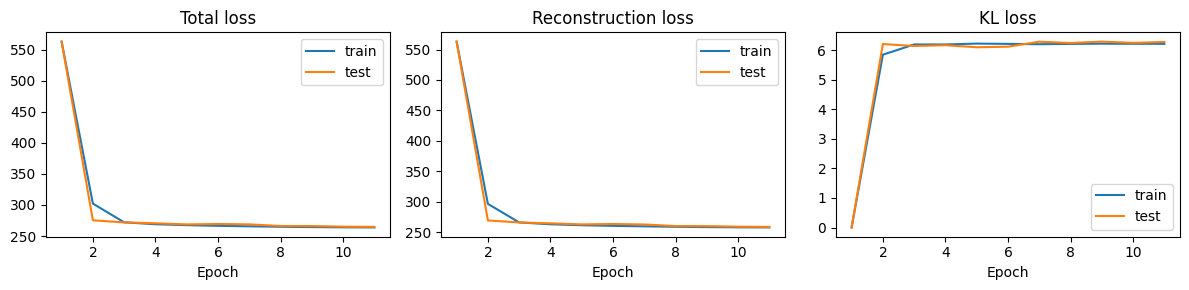

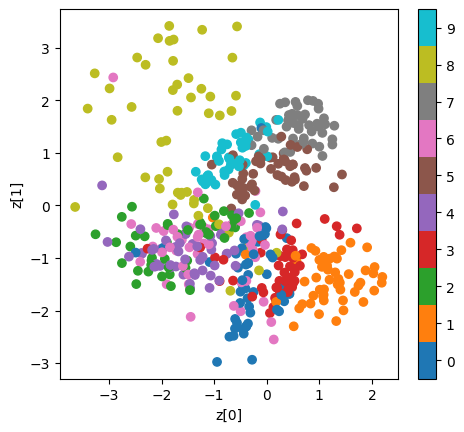

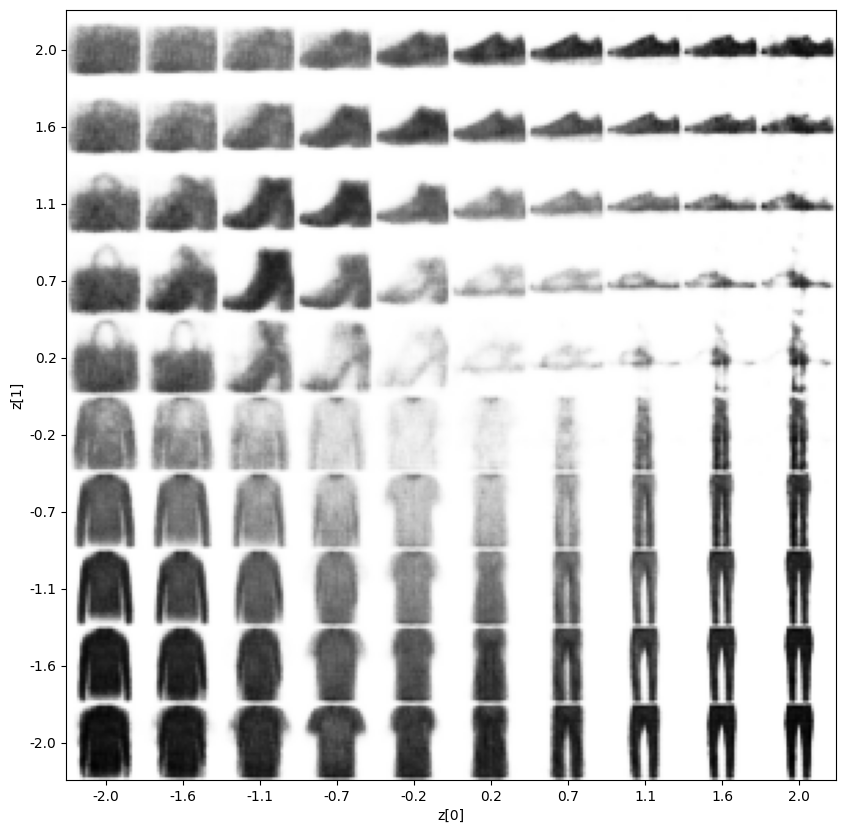

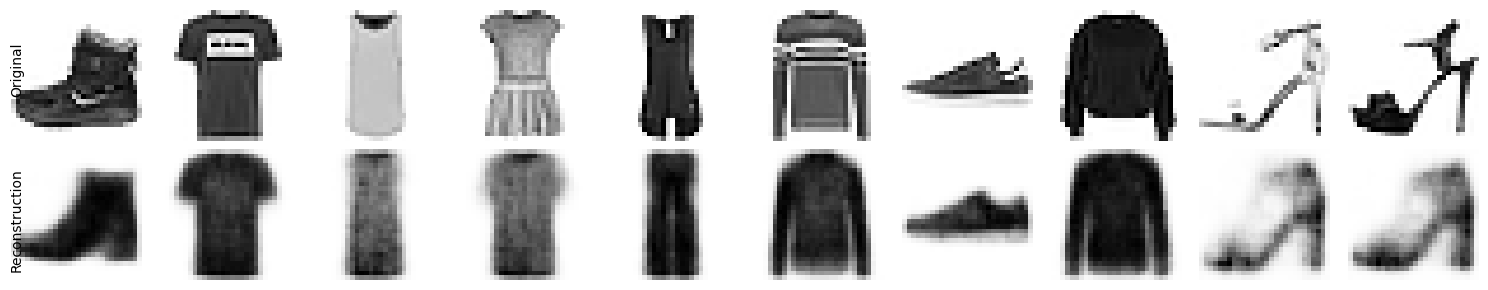

In [ ]:
# Configuration 1: Tiny architecture, 2D latent, fewer epochs
# fast to train, basic quality
model1 = make_vae(
    kernels_per_layer = (8, 16, 32),   # very few filters
    flat_size         = 32 * 7 * 7,    # = 1568
    latent_size       = 2              # 2D for visualisation
)

history1 = train_vae(
    model        = model1,
    train_loader = train_loader,
    test_loader  = test_loader,
    epochs       = 10,
    lr           = 1e-3,
    lmbda        = 1.0,
    device       = device
)

print(" Model 1: Small Architecture, latent=2, lmbda=1.0, epochs=10 ")
plot_history(history1)
plot_latent_points(model1.encoder, x_viz, y_viz)
plot_latent_space(model1.decoder)
plot_reconstructions(model1, x_viz)

Epoch   0/15 | train loss 540.84 (recon 540.80, KL 0.02) | test loss 540.86 (recon 540.82, KL 0.02)
Epoch   1/15 | train loss 290.36 (recon 269.06, KL 10.65) | test loss 267.55 (recon 246.70, KL 10.42)
Epoch   2/15 | train loss 262.93 (recon 240.52, KL 11.20) | test loss 262.20 (recon 240.56, KL 10.82)
Epoch   3/15 | train loss 259.73 (recon 237.40, KL 11.17) | test loss 259.68 (recon 237.31, KL 11.19)
Epoch   4/15 | train loss 257.76 (recon 235.52, KL 11.12) | test loss 258.35 (recon 236.14, KL 11.11)
Epoch   5/15 | train loss 256.46 (recon 234.27, KL 11.10) | test loss 257.70 (recon 235.64, KL 11.03)
Epoch   6/15 | train loss 255.58 (recon 233.40, KL 11.09) | test loss 257.01 (recon 234.44, KL 11.29)
Epoch   7/15 | train loss 254.78 (recon 232.69, KL 11.05) | test loss 256.23 (recon 234.58, KL 10.83)
Epoch   8/15 | train loss 254.23 (recon 232.13, KL 11.05) | test loss 255.36 (recon 232.83, KL 11.27)
Epoch   9/15 | train loss 253.71 (recon 231.66, KL 11.03) | test loss 254.98 (recon 

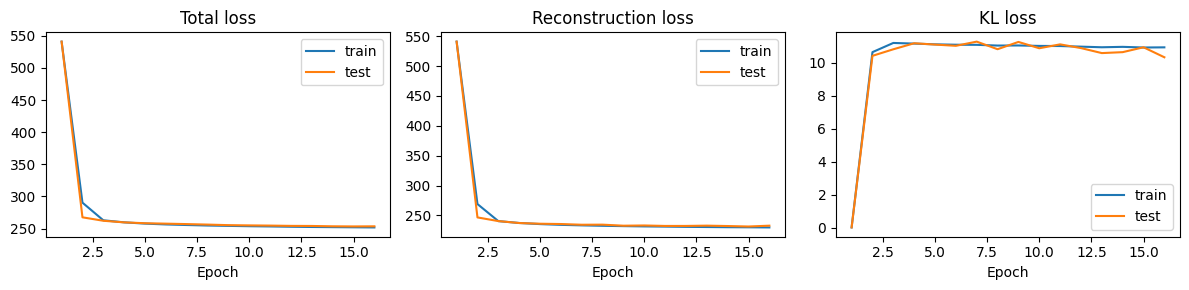

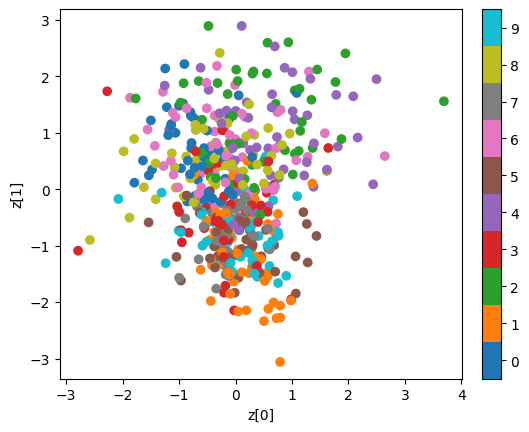

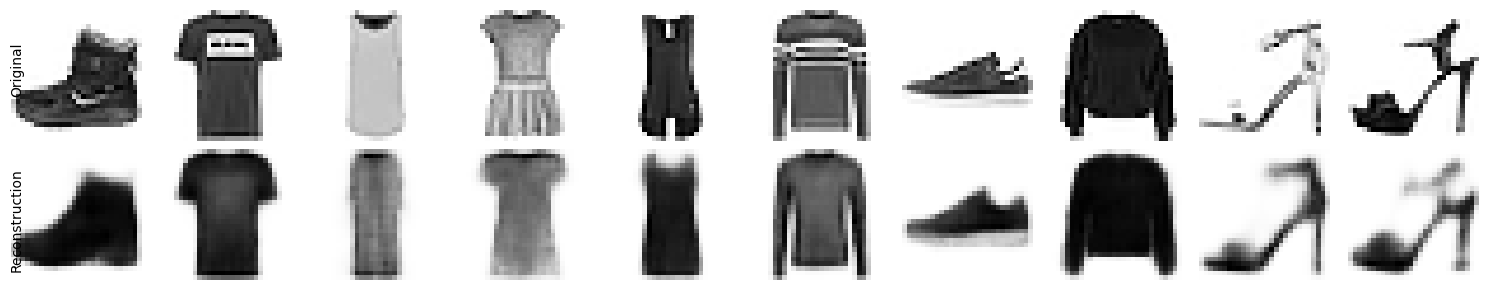

In [ ]:
# Configuration 2: Medium architecture, 16D latent, more epochs
# More capacity than model1
model2 = make_vae(
    kernels_per_layer = (16, 32, 64),  # medium filters
    flat_size         = 64 * 7 * 7,
    latent_size       = 16             # 16D latent space
)

history2 = train_vae(
    model        = model2,
    train_loader = train_loader,
    test_loader  = test_loader,
    epochs       = 15,
    lr           = 1e-3,
    lmbda        = 2.0,
    device       = device
)

print(" Model 2: Medium Architecture, latent=16, lmbda=2.0, epochs=15 ")
plot_history(history2)
plot_latent_points(model2.encoder, x_viz, y_viz)

plot_reconstructions(model2, x_viz)

Epoch   0/20 | train loss 538.92 (recon 538.92, KL 0.00) | test loss 538.94 (recon 538.94, KL 0.00)
Epoch   1/20 | train loss 283.19 (recon 276.56, KL 6.63) | test loss 276.05 (recon 268.63, KL 7.41)
Epoch   2/20 | train loss 269.49 (recon 262.89, KL 6.60) | test loss 268.17 (recon 261.52, KL 6.66)
Epoch   3/20 | train loss 266.81 (recon 260.27, KL 6.53) | test loss 272.04 (recon 264.90, KL 7.15)
Epoch   4/20 | train loss 264.81 (recon 258.42, KL 6.39) | test loss 264.88 (recon 258.53, KL 6.34)
Epoch   5/20 | train loss 263.39 (recon 257.07, KL 6.32) | test loss 263.78 (recon 257.37, KL 6.41)
Epoch   6/20 | train loss 262.72 (recon 256.40, KL 6.32) | test loss 263.94 (recon 257.73, KL 6.21)
Epoch   7/20 | train loss 261.83 (recon 255.54, KL 6.29) | test loss 263.60 (recon 256.96, KL 6.64)
Epoch   8/20 | train loss 260.94 (recon 254.65, KL 6.29) | test loss 262.47 (recon 255.98, KL 6.49)
Epoch   9/20 | train loss 260.62 (recon 254.30, KL 6.32) | test loss 262.04 (recon 255.54, KL 6.49)


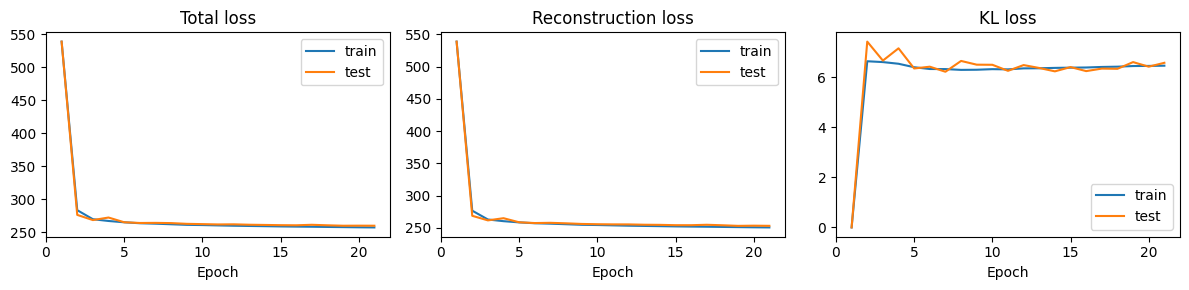

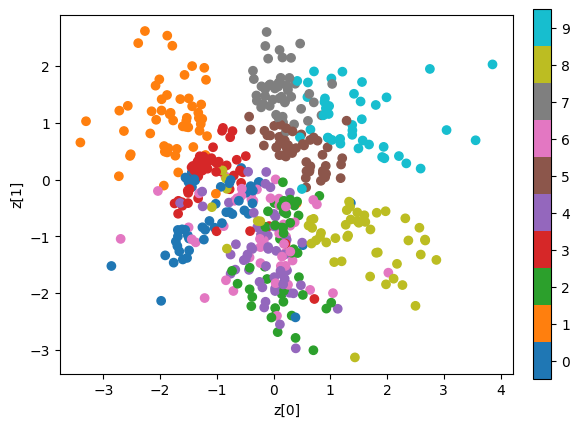

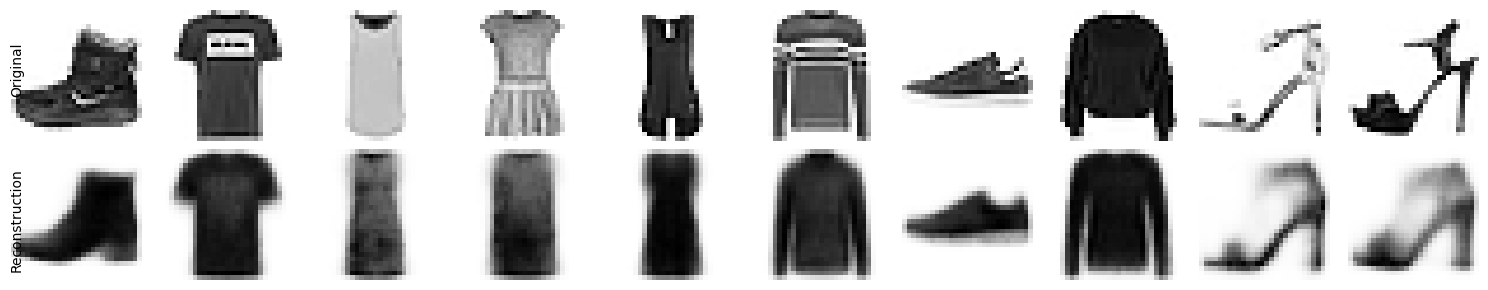

In [ ]:
# Configuration 3
model3 = make_vae(
    kernels_per_layer = (32, 64, 128),
    flat_size         = 128 * 7 * 7,
    latent_size       = 2
)

history3 = train_vae(
    model        = model3,
    train_loader = train_loader,
    test_loader  = test_loader,
    epochs       = 20,
    lr           = 1e-3,
    lmbda        = 1.0,
    device       = device
)

print(" Model 3: Large Architecture, latent=32, lmbda=1.0, epochs=20")
plot_history(history3)
plot_latent_points(model3.encoder, x_viz, y_viz)

plot_reconstructions(model3, x_viz)




In [ ]:
## YOUR CODE HERE

best_model = model2     # replace with whichever variable holds your best model


# Task: your results and conclusions

We trained three models, each changing something different, The first model was the smallest possible model. Fast to train and fully visualisable because latent_size=2 allows the latent space grid plot. It had basic reconstruction quality.
Model 2 has more filters, more latent dimensions, stronger KL regularisation, and more training time. It achieves the best reconstruction quality.
Model 3 has the biggest architecture and most training epochs. Latent space kept at 2D. Better than Model 1 but limited by the tiny latent space.

* Which model configuration was best? What is the evidence?

Model 2 ( Medium architecture, latent = 16, lambda = 2.0, epochs = 15) is the best configuration due to the following reasons :

1. It has the lowest reconstruction loss. Model 2 achieved a reconstruction loss of 230 as compared to model 3's 253 and model 1's 258. Reconstruction loss is the direct measure of how well the VAE is doing its core job, reconstructing and rebuilding images accurately.
2. Model 2 also had the best visual reconstruction as compared to the other models, model 2 produced sharp and detailed outputs particularly for complex items like dresses and heels.
3. Model 2's KL loss stabilised at ~11 and remained steady throughout training which confirms the latent distribution is well organised close to N(0,1).

Experimental design: Model 3 used a larger architecture
(32,64,128) but was limited to latent_size=2, which forced all information into just 2 numbers regardless of architecture size.
Model 2's 16D latent space allowed it to preserve much more information, which is why it achieves better reconstruction
quality despite a smaller architecture. With equal latent size,
Model 3's larger architecture would likely outperform Model 2.


* When you increase the latent space size, does reconstruction quality get better or worse?

Reconstruction quality gets better when the latent space size increases.
Model 1: latent_size=2  → recon loss = 258  
Model 2: latent_size=16 → recon loss = 230  
Model 3: latent_size=2  → recon loss = 253

A larger latent space gives the encoder more room to store information about each image. With only 2 dimensions, minute details like stripes, buckles, and thin heel shapes cannot all
be encoded simultaneously, the model must discard most of the detail to fit everything into just 2 numbers. With 16 dimensions,
the model retains much more detail, producing sharper reconstructions.

* When you increase the KL lambda term, does reconstruction quality get better or worse?

When the lambda is too large mode collapses, no variety in outputs
When he lambda is too small it is equivalent to classic AE

A larger lambda forces the encoder to push mu towards 0 and sigma towards 1 more aggressively. This makes the latent space more organised and easier to sample from, but the encoder has
less freedom to store image-specific information and so some reconstruction detail is lost. The optimal lambda balances these two competing goals.

The Model 2 has higher lambda and yet better reconstruction this is because it has a larger latent space which compensates for the stronger regularisation.



**References**


Week 08: Unsupervised Learning lecture notes ppt

https://www.datacamp.com/tutorial/variational-autoencoders

https://www.analyticsvidhya.com/blog/2023/07/an-overview-of-variational-autoencoders/

https://medium.com/@rekalantar/variational-auto-encoder-vae-pytorch-tutorial-dce2d2fe0f5f

https://medium.com/@mikelgda/implementing-a-variational-autoencoder-in-pytorch-ddc0bb5ea1e7

https://www.codecademy.com/article/variational-autoencoder-tutorial-vaes-explained

https://pyimagesearch.com/2023/10/02/a-deep-dive-into-variational-autoencoders-with-pytorch/


# Automated tests

Run the automated tests below. They should all return True.

In [ ]:
def run_tests(model, test_loader, device):
    """
    Run automated sanity checks on a trained VAE.
    Returns a dict mapping test name -> bool, plus scalar metrics.
    """

    # store the model status (training or eval)
    was_training = model.training

    # put model in eval mode
    model.eval()
    results = {}

    def check(name, condition, detail=""):
        results[name] = bool(condition)
        status = "PASS" if condition else "FAIL"
        print(f"  [{status}] {name}" + (f"  ({detail})" if detail else ""))

    print("── Structure ───────────────────────────────────────────────────")
    check("encoder_is_module",  isinstance(model.encoder, nn.Module))
    check("decoder_is_module",  isinstance(model.decoder, nn.Module))

    latent_size = model.encoder.latent_size

    print("── Forward pass shapes & values ────────────────────────────────")
    x_batch, _ = next(iter(test_loader))
    x_batch = x_batch[:16].to(device)
    with torch.no_grad():
        recon, mu, log_var = model(x_batch)

    check("output_shape_matches_input",
          recon.shape == x_batch.shape,  f"got {tuple(recon.shape)}")
    check("latent_shape_correct",
          mu.shape == (16, latent_size), f"got {tuple(mu.shape)}")
    check("mu_log_var_same_shape",  mu.shape == log_var.shape)
    check("recon_in_0_1",
          recon.min().item() >= 0 and recon.max().item() <= 1,
          f"range [{recon.min():.3f}, {recon.max():.3f}]")
    check("no_nan_or_inf",
          all(torch.isfinite(t).all().item() for t in (recon, mu, log_var)))

    print("── Training quality ────────────────────────────────────────────")
    total_recon = total_kl = 0.0
    with torch.no_grad():
        for x, _ in test_loader:
            x = x.to(device)
            r, m, lv = model(x)
            total_recon += F.binary_cross_entropy(r, x, reduction='sum').item()
            total_kl    += (-0.5 * torch.sum(1 + lv - m.pow(2) - lv.exp())).item()
    avg_recon = total_recon / len(test_loader.dataset)
    avg_kl    = total_kl    / len(test_loader.dataset)

    # Untrained model outputs ~0.5 everywhere → BCE ≈ 784 × log(2) ≈ 543
    check("recon_loss_below_untrained_baseline",
          avg_recon < 350,
          f"{avg_recon:.1f}  (untrained ≈ 543, good ≈ 230–260, threshold 350)")
    # KL ≈ 0 means encoder ignores input (posterior collapse)
    check("kl_not_collapsed",
          avg_kl > 1.0,
          f"{avg_kl:.2f} per image  (threshold > 1.0)")

    print("── Distinct outputs ────────────────────────────────────────────")
    x1, x2 = x_batch[:8], x_batch[8:]
    with torch.no_grad():
        r1, mu1, _ = model(x1)
        r2, mu2, _ = model(x2)
    check("different_inputs_give_different_recons",
          not torch.allclose(r1, r2, atol=1e-3))
    check("different_inputs_give_different_mu",
          not torch.allclose(mu1, mu2, atol=1e-3))

    print("── Generation from random z ────────────────────────────────────")
    z_rand = torch.randn(16, latent_size).to(device)
    with torch.no_grad():
        generated = model.decoder(z_rand)
    check("generated_in_0_1",
          generated.min().item() >= 0 and generated.max().item() <= 1)
    check("generated_non_constant",
          generated.std().item() > 0.01,
          f"std = {generated.std():.4f}")

    print("── Reconstruction vs random baseline ───────────────────────────")
    mse_recon  = F.mse_loss(r1, x1).item()
    mse_random = F.mse_loss(x2, x1).item()   # unrelated images as "random" baseline
    check("recon_closer_to_input_than_random_image",
          mse_recon < mse_random,
          f"recon MSE {mse_recon:.4f}  vs  random MSE {mse_random:.4f}")

    print("── Latent space spread ─────────────────────────────────────────")
    all_mu = []
    with torch.no_grad():
        for x, _ in test_loader:
            m, _ = model.encoder(x.to(device))
            all_mu.append(m.cpu())
    mu_std = torch.cat(all_mu).std(dim=0).mean().item()
    check("latent_space_has_spread",
          mu_std > 0.1,
          f"mean std of mu over test set = {mu_std:.3f}")

    n_pass = sum(results.values())
    n_total = len(results)

    model.train(was_training)

    print(f"\n{'─'*60}")
    print(f"  {n_pass}/{n_total} tests passed.")
    return results, avg_recon, avg_kl

In [ ]:
run_tests(best_model, test_loader, device)

── Structure ───────────────────────────────────────────────────
  [PASS] encoder_is_module
  [PASS] decoder_is_module
── Forward pass shapes & values ────────────────────────────────
  [PASS] output_shape_matches_input  (got (16, 1, 28, 28))
  [PASS] latent_shape_correct  (got (16, 16))
  [PASS] mu_log_var_same_shape
  [PASS] recon_in_0_1  (range [0.000, 0.971])
  [PASS] no_nan_or_inf
── Training quality ────────────────────────────────────────────
  [PASS] recon_loss_below_untrained_baseline  (232.8  (untrained ≈ 543, good ≈ 230–260, threshold 350))
  [PASS] kl_not_collapsed  (10.34 per image  (threshold > 1.0))
── Distinct outputs ────────────────────────────────────────────
  [PASS] different_inputs_give_different_recons
  [PASS] different_inputs_give_different_mu
── Generation from random z ────────────────────────────────────
  [PASS] generated_in_0_1
  [PASS] generated_non_constant  (std = 0.2930)
── Reconstruction vs random baseline ───────────────────────────
  [PASS] recon_cl

({'encoder_is_module': True,
  'decoder_is_module': True,
  'output_shape_matches_input': True,
  'latent_shape_correct': True,
  'mu_log_var_same_shape': True,
  'recon_in_0_1': True,
  'no_nan_or_inf': True,
  'recon_loss_below_untrained_baseline': True,
  'kl_not_collapsed': True,
  'different_inputs_give_different_recons': True,
  'different_inputs_give_different_mu': True,
  'generated_in_0_1': True,
  'generated_non_constant': True,
  'recon_closer_to_input_than_random_image': True,
  'latent_space_has_spread': True},
 232.78493889160157,
 10.336544387817383)